# Agente Multimodal de Nueva Generación: Qwen2.5-VL

### Audio + Imagen → Texto con resolución dinámica

Este notebook presenta **Qwen2.5-VL-3B-Instruct**, un modelo multimodal de visión-lenguaje de última generación (2025), como evolución natural del pipeline BLIP-2 + Whisper estudiado anteriormente.

| **Aspecto** | **BLIP-2 (flan-t5-xl)** | **Qwen2.5-VL-3B** |
|---|---|---|
| Año de publicación | 2023 | 2025 |
| Parámetros totales | ~3B + ViT congelado (separado) | ~3B (arquitectura unificada) |
| Resolución de imagen | **Fija: 224×224 px** | **Dinámica: hasta 1280 px** |
| Mecanismo visual | Q-Former como puente | ViT dinámico + RoPE 2D nativo |
| OCR (texto en imágenes) | ❌ Débil | ✅ Excelente |
| Conversación multi-turno | ❌ No | ✅ Sí |
| Soporte de video | ❌ No | ✅ Sí |
| VRAM requerida (fp16) | ~16 GB | ~8 GB (4-bit: ~4 GB) |
| Corre en T4/P100 Kaggle | ⚠️ Justo | ✅ Cómodo |
| Licencia | BSD 3-Clause | Apache 2.0 |

### Diferencia arquitectónica clave

**BLIP-2** separa el encoder visual (ViT congelado) del LLM (FLAN-T5 congelado) mediante un Q-Former ligero entrenado como puente. La imagen **siempre** se redimensiona a 224×224 px antes de procesarse, perdiendo detalles finos.

**Qwen2.5-VL** usa un **ViT de resolución dinámica** (*Naive Dynamic Resolution*): divide la imagen en parches de tamaño variable preservando la resolución original. Incorpora **RoPE 2D** (Rotary Position Embeddings bidimensionales) para codificar la posición espacial de cada parche, lo que mejora drásticamente la comprensión de documentos, texto en imágenes y escenas complejas.

In [9]:
# ── Instalación de dependencias ──────────────────────────────────────────────
!pip install -q transformers>=4.49.0 accelerate qwen-vl-utils bitsandbytes

# Carga de modelos

### `openai/whisper-base` — Reconocimiento Automático de Voz (ASR)

Whisper es un modelo Transformer encoder-decoder entrenado por OpenAI en 680,000 horas de audio supervisado. Convierte señales de audio en texto mediante un espectrograma log-Mel de 80 canales como representación intermedia.

| **Feature** | **Description** |
|---|---|
| **Arquitectura** | Transformer Encoder-Decoder |
| **Parámetros** | 74M (variante base) |
| **Entrada** | Audio (wav, mp3, flac) |
| **Salida** | Texto transcrito |
| **Idiomas** | 99 idiomas (multilingüe) |
| **Datos de entrenamiento** | 680,000 horas de audio supervisado |
| **Licencia** | MIT |

### `Qwen/Qwen2.5-VL-3B-Instruct` — Visión + Lenguaje

Qwen2.5-VL es el modelo de visión-lenguaje más reciente de Alibaba Cloud. Usa cuantización 4-bit (`bitsandbytes`) para reducir el uso de VRAM de ~8 GB (fp16) a ~4 GB.

| **Feature** | **Description** |
|---|---|
| **Arquitectura** | ViT dinámico + Transformer Decoder (Qwen2.5) |
| **Parámetros** | ~3B |
| **Entrada** | Imagen + Texto (también video) |
| **Resolución de imagen** | Dinámica (hasta 1280×1280 px) |
| **Max tokens de entrada** | 32,768 tokens |
| **Tareas** | VQA, captioning, OCR, razonamiento visual, multi-turno |
| **Licencia** | Apache 2.0 |
| **Repositorio** | [Qwen2.5-VL en Hugging Face](https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct) |

In [ ]:
from transformers import (
    pipeline,
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
    Blip2ForConditionalGeneration,
    Blip2Processor
)
from qwen_vl_utils import process_vision_info
from PIL import Image
from IPython.display import Audio, display
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {device}")

# ── Whisper-base: transcripción de audio ─────────────────────────────────────
asr_pipe = pipeline("automatic-speech-recognition", model="openai/whisper-base")
print("✅ Whisper cargado")

# ── Qwen2.5-VL-3B con cuantización 4-bit ────────────────────────────────────
# BitsAndBytesConfig reduce VRAM de ~8 GB (fp16) a ~4 GB (4-bit)
# Ideal para GPUs T4/P100 de Kaggle con 16 GB de VRAM
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

qwen_model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(qwen_model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    qwen_model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

print(f"✅ Qwen2.5-VL cargado en: {next(model.parameters()).device}")

# ── BLIP-2 (flan-t5-xl) para comparaciones ───────────────────────────────────
blip_model_id = "Salesforce/blip2-flan-t5-xl"
blip_processor = Blip2Processor.from_pretrained(blip_model_id)
blip_model = Blip2ForConditionalGeneration.from_pretrained(
    blip_model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print(f"✅ BLIP-2 cargado en: {next(blip_model.parameters()).device}")

Dispositivo disponible: cuda


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

✅ Whisper cargado


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

✅ Qwen2.5-VL cargado en: cuda:0


# Función del agente: Audio + Imagen → Texto

In [11]:
def response_generation(audio_path, image_path, max_new_tokens=256):
    """
    Pipeline multimodal: Audio + Imagen → Texto

    Pasos:
      1. Reproduce y transcribe el audio con Whisper.
      2. Carga y muestra la imagen (resolución original preservada).
      3. Construye un mensaje de chat estructurado con imagen + pregunta.
      4. Genera la respuesta con Qwen2.5-VL.

    A diferencia de BLIP-2, Qwen utiliza un formato de chat (messages)
    que permite conversaciones multi-turno y procesa la imagen en su
    resolución original sin redimensionar a 224×224 px.

    Args:
        audio_path     : ruta al archivo de audio (.mp3, .wav, .flac)
        image_path     : ruta a la imagen (.jpg, .png, etc.)
        max_new_tokens : máximo de tokens a generar en la respuesta
    """
    # ── 1. Audio ─────────────────────────────────────────────────────────────
    display(Audio(audio_path))
    transcription = asr_pipe(audio_path)["text"]
    print(f"\n🎙️  Transcripción (Whisper): {transcription}")

    # ── 2. Imagen ─────────────────────────────────────────────────────────────
    image = Image.open(image_path).convert("RGB")
    print(f"📐 Resolución original: {image.size[0]}×{image.size[1]} px  "
          f"(Qwen la procesa completa; BLIP-2 la reduciría a 224×224 px)")
    display(image)

    # ── 3. Construcción del mensaje de chat ───────────────────────────────────
    # Qwen usa un formato de mensajes estructurado (similar a ChatGPT)
    # que permite mezclar imágenes y texto de forma natural.
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text",  "text": transcription}
        ]
    }]

    # apply_chat_template añade los tokens especiales del formato de chat de Qwen
    text_prompt = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # process_vision_info extrae y preprocesa las imágenes del mensaje
    image_inputs, _ = process_vision_info(messages)

    inputs = processor(
        text=[text_prompt],
        images=image_inputs,
        return_tensors="pt"
    ).to(model.device)

    # ── 4. Generación ─────────────────────────────────────────────────────────
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False  # greedy decoding: determinista y reproducible
        )

    # Decodificar solo los tokens nuevos (excluir el prompt de entrada)
    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    answer = processor.decode(generated_ids[0], skip_special_tokens=True)

    # ── 5. Resultado ──────────────────────────────────────────────────────────
    print("\n" + "─"*55)
    print("🤖 Respuesta del agente multimodal (Qwen2.5-VL):")
    print("─"*55)
    print(f"  Pregunta (del audio) : {transcription}")
    print(f"  Respuesta (del modelo): {answer}")

# Pruebas del modelo

## Prueba 1 — Pregunta sobre imagen de un automóvil


🎙️  Transcripción (Whisper):  How many pets are there in the photo?
📐 Resolución original: 640×480 px  (Qwen la procesa completa; BLIP-2 la reduciría a 224×224 px)


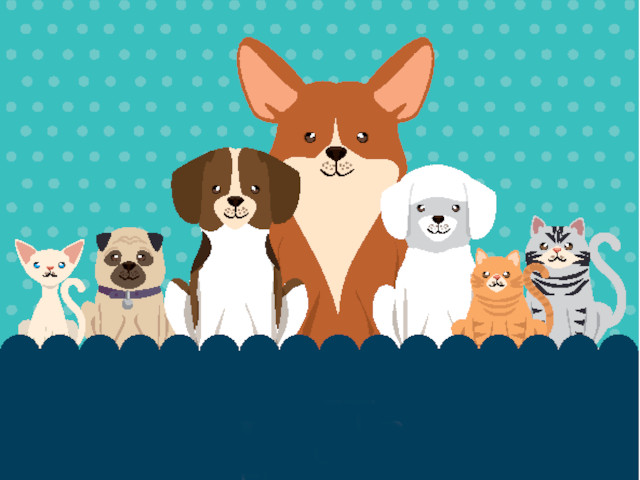


───────────────────────────────────────────────────────
🤖 Respuesta del agente multimodal (Qwen2.5-VL):
───────────────────────────────────────────────────────
  Pregunta (del audio) :  How many pets are there in the photo?
  Respuesta (del modelo): There are 8 pets in the photo.


In [12]:
audio_path = "/kaggle/input/datasets/reinaldolopeznarvaez/clase-5-si/output.mp3"
image_path = "/kaggle/input/datasets/reinaldolopeznarvaez/clase-5-si/segurmania_mascotas_destacada.jpg"

response_generation(audio_path, image_path)

## Prueba 2 — Reconocimiento de emoción facial


🎙️  Transcripción (Whisper):  What is the main emotion shown in this photo?
📐 Resolución original: 318×159 px  (Qwen la procesa completa; BLIP-2 la reduciría a 224×224 px)


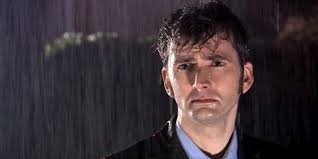


───────────────────────────────────────────────────────
🤖 Respuesta del agente multimodal (Qwen2.5-VL):
───────────────────────────────────────────────────────
  Pregunta (del audio) :  What is the main emotion shown in this photo?
  Respuesta (del modelo): The main emotion shown in this photo appears to be sadness or melancholy. The subject's expression, combined with the rainy background, conveys a sense of sorrow or contemplation.


In [13]:
response_generation(
    "/kaggle/input/datasets/reinaldolopeznarvaez/si-2026-i/Multimodal - Week 5/Exercise 2/emotion.mp3",
    "/kaggle/input/datasets/reinaldolopeznarvaez/si-2026-i/Multimodal - Week 5/Exercise 2/emotion.jpg"
)

## Prueba 3 — OCR: lectura de texto en imágenes

Esta prueba evidencia una ventaja arquitectónica concreta de Qwen2.5-VL sobre BLIP-2:
la **resolución dinámica** preserva detalles finos como texto pequeño en documentos,
señales, capturas de pantalla o facturas. BLIP-2, al reducir a 224×224 px, pierde
esta información de forma irreversible.

Carga cualquier imagen que contenga texto visible (captura de pantalla, cartel, documento, etc.).

📐 Resolución original: 594×390 px


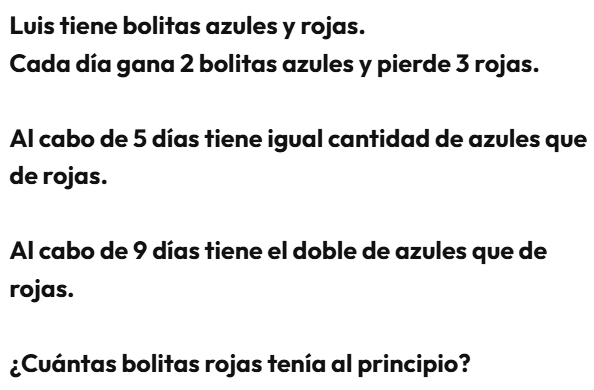


🤖 Respuesta: Luis tiene bolitas azules y rojas.
Cada día gana 2 bolitas azules y pierde 3 rojas.
Al cabo de 5 días tiene igual cantidad de azules que de rojas.
Al cabo de 9 días tiene el doble de azules que de rojas.
¿Cuántas bolitas rojas tenía al principio?


'Luis tiene bolitas azules y rojas.\nCada día gana 2 bolitas azules y pierde 3 rojas.\nAl cabo de 5 días tiene igual cantidad de azules que de rojas.\nAl cabo de 9 días tiene el doble de azules que de rojas.\n¿Cuántas bolitas rojas tenía al principio?'

In [14]:
# ── Prueba OCR con pregunta de texto (sin audio) ─────────────────────────────
# En esta prueba formulamos la pregunta directamente como texto
# para aislar la capacidad de comprensión visual del modelo.

def response_text(image_path, question, max_new_tokens=256):
    """Versión simplificada: acepta pregunta como texto en lugar de audio."""
    image = Image.open(image_path).convert("RGB")
    print(f"📐 Resolución original: {image.size[0]}×{image.size[1]} px")
    display(image)

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text",  "text": question}
        ]
    }]
    text_prompt = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(
        text=[text_prompt], images=image_inputs, return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    answer = processor.decode(generated_ids[0], skip_special_tokens=True)
    print(f"\n🤖 Respuesta: {answer}")
    return answer


# Reemplaza con una imagen que contenga texto visible
image_path_ocr = "/kaggle/input/datasets/reinaldolopeznarvaez/text-in-image/Screenshot 2025-02-07 122404.png"  # <── modificar
response_text(image_path_ocr, "What text do you see in this image? Transcribe it exactly.")

## Prueba 4 — Conversación multi-turno

A diferencia de BLIP-2, Qwen2.5-VL soporta conversaciones de múltiples turnos:
el modelo recuerda el contexto de la imagen y las respuestas anteriores.
Esto es fundamental para aplicaciones de asistentes interactivos.

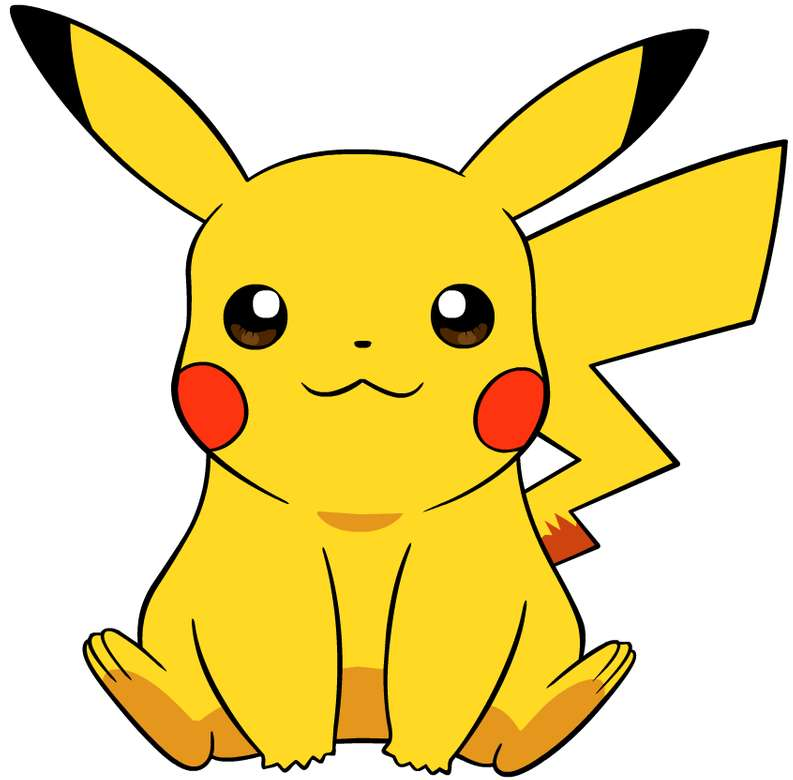


👤 Turno 1 — Pregunta : Who's that Pokémon?
🤖 Turno 1 — Respuesta: This is Pikachu, a popular Pokémon character from the Pokémon series. Pikachu is known for its yellow color, red cheeks, and lightning-shaped tail. It is one of the most recognizable Pokémon characters and has become a cultural icon.

👤 Turno 2 — Pregunta : Based on your previous answer, what are the most distinctive physical features of this Pokémon?
🤖 Turno 2 — Respuesta: The most distinctive physical features of Pikachu include its bright yellow color, red cheeks, and lightning-shaped tail. These features make Pikachu easily recognizable and beloved by fans around the world..

👤 Turno 3 — Pregunta : What colors does this Pokémon have and what abilities or characteristics is it known for?
🤖 Turno 3 — Respuesta: Pikachu has bright yellow fur with red cheeks and a lightning-shaped tail. It is known for its ability to generate electricity from its body, which can be used as a weapon or attack. Pikachu is also known for i

In [15]:
def multiturn_chat(image_path, questions):
    """
    Conversación multi-turno sobre una imagen.
    El historial se acumula en `messages` para que el modelo
    pueda referenciar turnos anteriores.

    Args:
        image_path : ruta a la imagen
        questions  : lista de preguntas en orden
    """
    image = Image.open(image_path).convert("RGB")
    display(image)

    # El primer turno incluye la imagen; los siguientes solo texto
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text",  "text": questions[0]}
        ]
    }]

    for i, question in enumerate(questions):
        if i > 0:
            messages.append({"role": "user", "content": question})

        text_prompt = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        image_inputs, _ = process_vision_info(messages)
        inputs = processor(
            text=[text_prompt], images=image_inputs, return_tensors="pt"
        ).to(model.device)

        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=200, do_sample=False)

        generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
        answer = processor.decode(generated_ids[0], skip_special_tokens=True)

        print(f"\n👤 Turno {i+1} — Pregunta : {question}")
        print(f"🤖 Turno {i+1} — Respuesta: {answer}")

        # Agregar la respuesta del modelo al historial
        messages.append({"role": "assistant", "content": answer})


# Ejemplo: 3 turnos sobre la imagen del automóvil
multiturn_chat(
    image_path="/kaggle/input/datasets/reinaldolopeznarvaez/clase-5-si/pikachu.jpg",
    questions=[
        "Who's that Pokémon?",
        "Based on your previous answer, what are the most distinctive physical features of this Pokémon?",
        "What colors does this Pokémon have and what abilities or characteristics is it known for?"
    ]
)

# Actividades

1. Comparación multimodal (audio + imagen)

    Sube **una imagen de tu elección** (por ejemplo, un carro, un animal o una escena cotidiana). Luego **graba o sube un audio corto** haciendo una pregunta sobre la imagen. El audio será procesado con **Whisper** para convertirlo en texto. Usa ese texto como prompt junto con la imagen y ejecuta el modelo **Qwen-VL**. Establece **max_new_tokens en 1000** y observa la respuesta generada.

    Repite exactamente el mismo procedimiento utilizando el modelo **BLIP-2** con la misma imagen y el mismo prompt. Compara las respuestas de ambos modelos. **¿Cuál describe mejor la imagen? ¿Cuál parece entender mejor la pregunta? Escribe una breve conclusión sobre las diferencias observadas.**


2. Comparación de OCR

    Sube **una imagen que contenga texto** (por ejemplo, una señal, un menú, una página de un libro o una captura de pantalla). Ejecuta el modelo **Qwen-VL** con un prompt como *“Read all the text in this image.”*. Observa qué texto es capaz de identificar el modelo.

    Luego ejecuta **BLIP-2** utilizando la **misma imagen y el mismo prompt**. Compara los resultados de ambos modelos. **¿Cuál reconoce más texto? ¿Hay errores o partes omitidas? Describe brevemente las diferencias entre los resultados.**


3. Conversación iterativa con la imagen

    Sube **una imagen de tu elección** y utilízala con el modelo **Qwen-VL**. Realiza una primera pregunta general sobre la imagen, por ejemplo: *“What objects appear in this image?”*. Luego formula una segunda pregunta relacionada con la respuesta anterior y finalmente una tercera pregunta que dependa del contexto.

    Observa si el modelo mantiene el contexto entre las preguntas. **¿Las respuestas son coherentes entre sí? ¿El modelo recuerda la información de turnos anteriores? Escribe una breve conclusión sobre el comportamiento del modelo en una conversación iterativa.**
